# 5. Bonus: response to the metronome, MMN and P3a

A 2 Hz metronome, with every eighth beat deviant, plays during all recordings, but there are no markers. For each recording both the beat phase (0 to 0.5 s) and the position of the deviant (one of eight) are unknown.

**Approach without markers.** The recording is cut into 4-second cycles of eight beats and averaged. The spectrum of the average cycle is split into two subspaces:

| Subspace | Frequencies | Contains |
| --- | --- | --- |
| grid | multiples of 2 Hz | the response to every beat |
| deviant | k/4 Hz, not multiples of 1 Hz | a response that repeats every 4 s |

Even and odd cycles form two independent halves; if a response exists, their shapes agree. A random control shifts one half and repeats the whole search 2000 times.

Order of work: pilot, then validation on the open ERP CORE data and a hybrid simulation, then one confirmatory test.

In [1]:
import json
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from src import config, erp_core, metronome, metronome_sim, viz
from src.dataset import load_record, scan_dataset

warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation"
FP_COLOR, OTHER_COLOR, NULL_COLOR = viz.COHORT_COLORS[config.GROUP_PTSD], viz.COHORT_COLORS[config.GROUP_CONTROL], viz.TEXT_MUTED

## 5.0 Bonus condition

The lower bound of the 95% confidence interval of the main model's AUC must be above 0.5.

In [2]:
p8 = json.loads((VALIDATION / "protocol8" / "metrics.json").read_text(encoding="utf-8"))
bonus_condition = pd.DataFrame(
    {name: p8[key]["auc_ptsd_vs_controls_excl_ageing"] for name, key in [("before calibration", "p_raw"), ("after calibration", "p")]}
).T.rename(columns={"value": "AUC", "ci_low": "lower 95% bound", "ci_high": "upper 95% bound"})
bonus_condition["bonus condition (lower bound > 0.5)"] = bonus_condition["lower 95% bound"] > 0.5
bonus_condition

,AUC,lower 95% bound,upper 95% bound,bonus condition (lower bound > 0.5)
before calibration,0.864,0.796,0.919,True
after calibration,0.824,0.753,0.886,True


## 5.1 What in the recordings is locked to the metronome

Rest recordings of formats A and B. For each frequency k/4 Hz we measure how well the phases of the two halves agree (Fp1/Fp2). Without a signal the mean is close to zero.

In [3]:
registry, _, subjects = scan_dataset()
registry = registry.join(subjects[["has_task_files"]], on="subject_key")
rows = metronome.analysis_records(registry, "rest")
rows["stratum"] = rows.apply(metronome.stratum, axis=1)
all_spectra = Parallel(n_jobs=-1)(delayed(metronome.record_cycle_spectra)(config.DATA_DIR / rel) for rel in rows["relpath"])

valid = np.array([s.valid(metronome.FRONTAL) for s in all_spectra])
rows = rows[valid].reset_index(drop=True)
spectra = [s for s, v in zip(all_spectra, valid) if v]
subject = pd.factorize(rows["subject_key"])[0]
print(f"rest recordings A/B: {valid.size}, analysed: {valid.sum()}, subjects: {np.unique(subject).size}")
rows["stratum"].value_counts().rename("recordings").to_frame().T

rest recordings A/B: 181, analysed: 155, subjects: 155


stratum,somatoform,control_B_supplement,control_ageing,control_A,ptsd,control_B
recordings,54,39,20,20,20,2


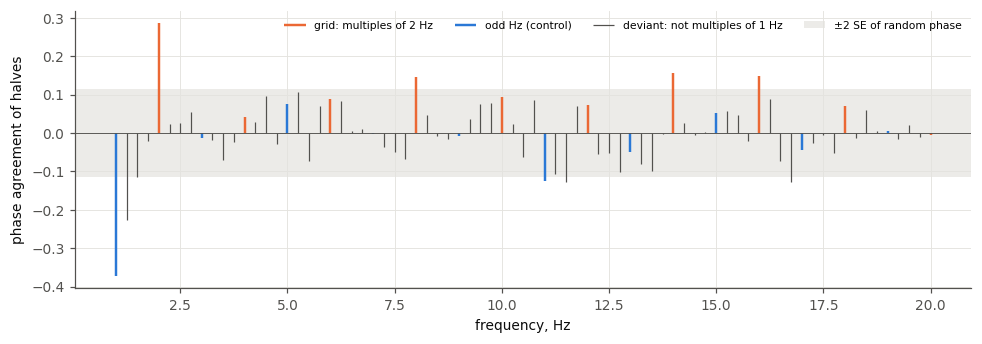

,2 Hz,4 Hz,6 Hz,8 Hz,10 Hz
phase agreement,0.286,0.043,0.089,0.146,0.094


In [4]:
fp = np.stack([s.channel_mean(metronome.FRONTAL) for s in spectra])
a, b = fp[:, 0], fp[:, 1]
consistency = (np.real(a * b.conj()) / (np.abs(a) * np.abs(b))).mean(axis=0)
freqs = np.arange(metronome.N_BINS) * metronome.BIN_HZ
k = np.arange(metronome.N_BINS)
band = (freqs >= metronome.BAND_HZ[0]) & (freqs <= metronome.BAND_HZ[1])
chance = 2 * np.sqrt(0.5 / len(spectra))

fig, ax = plt.subplots(figsize=(9, 3.2))
for sel, color, label in [
    (band & (k % 8 == 0), FP_COLOR, "grid: multiples of 2 Hz"),
    (band & (k % 4 == 0) & (k % 8 != 0), OTHER_COLOR, "odd Hz (control)"),
    (band & (k % 4 != 0), NULL_COLOR, "deviant: not multiples of 1 Hz"),
]:
    ax.vlines(freqs[sel], 0, consistency[sel], color=color, lw=1.6 if color != NULL_COLOR else 0.8, label=label)
ax.axhspan(-chance, chance, color=viz.GRID, alpha=0.7, lw=0, label="±2 SE of random phase")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("frequency, Hz")
ax.set_ylabel("phase agreement of halves")
ax.legend(fontsize=7, ncol=4, loc="upper right")
plt.tight_layout()
plt.show()
pd.Series(consistency[[8, 16, 24, 32, 40]], index=["2 Hz", "4 Hz", "6 Hz", "8 Hz", "10 Hz"], name="phase agreement").to_frame().T

Agreement is highest at 2 Hz, the beat rate, and is also visible at some other multiples of 2 Hz, but not at odd frequencies. The negative agreement at 0.75 to 1.5 Hz is an artefact of splitting into even and odd cycles, checked below.

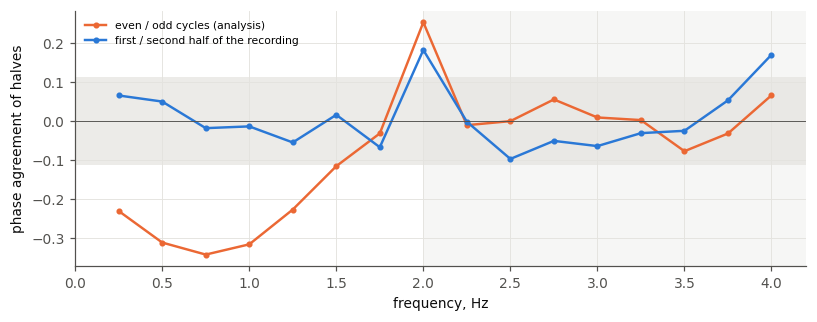

In [5]:
consistency_split = [
    r for r in Parallel(n_jobs=-1)(
        delayed(lambda rel: metronome.split_phase_consistency(load_record(config.DATA_DIR / rel)))(rel) for rel in rows["relpath"]
    ) if r is not None
]
low = (freqs > 0) & (freqs <= 4)
fig, ax = plt.subplots(figsize=(7.5, 3.0))
for name, color, label in [("interleaved", FP_COLOR, "even / odd cycles (analysis)"), ("blocks", OTHER_COLOR, "first / second half of the recording")]:
    mean = np.mean([r[name] for r in consistency_split], axis=0)
    ax.plot(freqs[low], mean[low], marker="o", ms=3, color=color, label=label)
ax.axhspan(-chance, chance, color=viz.GRID, alpha=0.7, lw=0)
ax.axvspan(*metronome.CONFIRM_BAND_HZ, color=viz.GRID, alpha=0.3, lw=0)
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("frequency, Hz")
ax.set_ylabel("phase agreement of halves")
ax.set_xlim(0, 4.2)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

When the recording is split into its first and second half, the dip disappears and the 2 Hz peak remains. The random control removes the dip as well, so it only makes the tests stricter, and the 2–8 Hz band of the confirmatory test does not contain it.

## 5.2 The hardware filter

The order of the 2 Hz hardware high-pass filter is estimated from our spectra: a power-law background times the response of an n-th order Butterworth filter, fitted on 0.3–6.5 Hz.

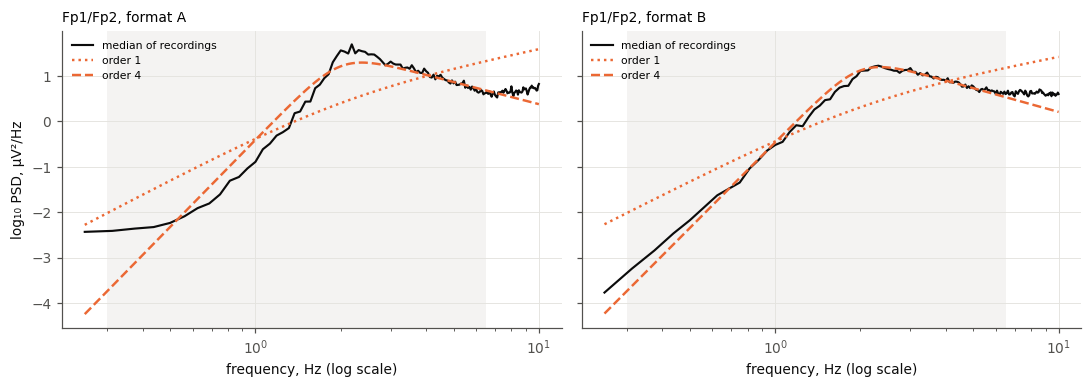

filter order,"residual, order 1","residual, order 2","residual, order 3","residual, order 4"
format A (74 recordings),33.053,17.90,8.524,5.689
format B (81 recordings),22.798,9.21,1.732,0.835


In [6]:
lowfreq = Parallel(n_jobs=-1)(delayed(metronome_sim.fp_lowfreq_spectrum)(config.DATA_DIR / rel) for rel in rows["relpath"])
lf_freqs = lowfreq[0][0]
lf_log = np.log10(np.stack([p for _, p in lowfreq]))
fits = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, family in zip(axes, ("A", "B")):
    m = (rows["export_family"] == family).to_numpy()
    median = np.median(lf_log[m], axis=0)
    fit = metronome_sim.highpass_order_fit(lf_freqs, median)
    fits[f"format {family} ({m.sum()} recordings)"] = fit["ssr"]
    sel = (lf_freqs >= 0.2) & (lf_freqs <= 10)
    ax.plot(lf_freqs[sel], median[sel], color="#0b0b0b", lw=1.4, label="median of recordings")
    for order, style in [(1, ":"), (4, "--")]:
        c, chi = fit.loc[order, ["c", "chi"]]
        model = c - chi * np.log10(lf_freqs[sel]) + 2 * np.log10(np.abs(erp_core.highpass_response(lf_freqs[sel], order)))
        ax.plot(lf_freqs[sel], model, style, color=FP_COLOR, label=f"order {order}")
    ax.axvspan(*metronome_sim.ORDER_FIT_BAND_HZ, color=viz.GRID, alpha=0.4, lw=0)
    ax.set_xscale("log")
    ax.set_xlabel("frequency, Hz (log scale)")
    ax.set_title(f"Fp1/Fp2, format {family}", loc="left", fontsize=9)
    ax.legend(fontsize=7)
axes[0].set_ylabel("log₁₀ PSD, µV²/Hz")
plt.tight_layout()
plt.show()
pd.DataFrame(fits).rename_axis("filter order").T.rename(columns=lambda n: f"residual, order {n}")

A fourth-order filter fits best (24 dB per octave). From here on a causal fourth-order filter at 2 Hz is emulated.

## 5.3 MMN from open data under our conditions

ERP CORE (Kappenman et al., 2021; CC BY-SA 4.0): 40 adults, passive oddball, the deviant tone is 10 dB quieter. First we check that the published MMN is reproduced, then how it looks at Fp1/Fp2 after the headset filter.

In [7]:
if not any(erp_core.DEFAULT_DIR.glob(f"*{erp_core.ERPSET_SUFFIX}")):
    erp_core.download_erpsets()
erp_metrics, erp_curves = erp_core.summary(erp_core.load_all())
erp_table = pd.DataFrame(erp_metrics).T[
    ["mmn_window_mean_uv", "mmn_window_share_negative", "difference_extremum_uv", "difference_extremum_latency_s", "difference_rms_0_600ms_uv"]
].rename(columns={
    "mmn_window_mean_uv": "mean 125–225 ms, µV",
    "mmn_window_share_negative": "share of participants < 0",
    "difference_extremum_uv": "extremum 50–400 ms, µV",
    "difference_extremum_latency_s": "extremum latency, s",
    "difference_rms_0_600ms_uv": "RMS 0–600 ms, µV",
})
erp_table

,"mean 125–225 ms, µV",share of participants < 0,"extremum 50–400 ms, µV","extremum latency, s","RMS 0–600 ms, µV"
FCz,-1.848,0.950,-2.819,0.191,0.968
Fp,-1.179,0.950,-1.719,0.188,0.590
Fp HP1,-0.647,0.925,-1.061,0.180,0.388
Fp HP2,-0.391,0.875,1.217,0.250,0.401
Fp HP4,-0.046,0.450,1.240,0.242,0.407
C5/C6 HP4,-0.143,0.625,1.114,0.246,0.434
O1/O2 HP4,-0.000,0.400,0.328,0.246,0.125


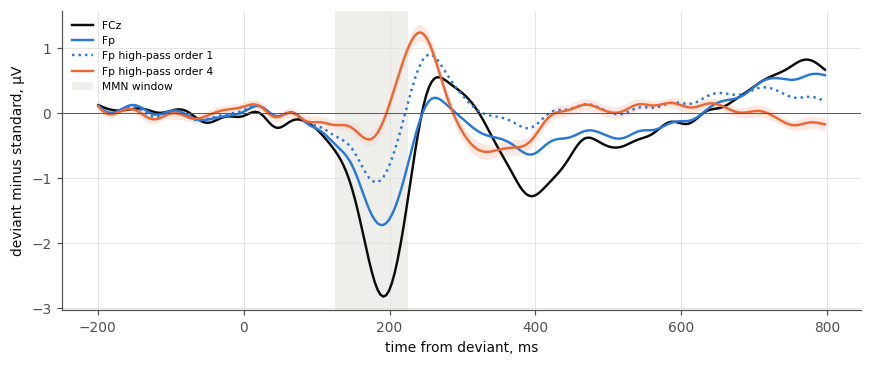

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for view, color, style in [("FCz", "#0b0b0b", "-"), ("Fp", OTHER_COLOR, "-"), ("Fp HP1", OTHER_COLOR, ":"), ("Fp HP4", FP_COLOR, "-")]:
    d = erp_curves[(erp_curves["view"] == view) & (erp_curves["wave"] == "difference")]
    ax.plot(d["time_s"] * 1000, d["mean_uv"], style, color=color, label=view.replace("HP", "high-pass order "))
    if view == "Fp HP4":
        ax.fill_between(d["time_s"] * 1000, d["mean_uv"] - d["sem_uv"], d["mean_uv"] + d["sem_uv"], color=color, alpha=0.15, lw=0)
ax.axvspan(125, 225, color=viz.GRID, alpha=0.6, lw=0, label="MMN window")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("time from deviant, ms")
ax.set_ylabel("deviant minus standard, µV")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

The published MMN at FCz is reproduced. After the headset filter, most of the response energy at Fp remains, but the shape becomes a negative, positive, negative wave with a positive peak around 250 ms. Energy-based statistics are therefore needed, and a positivity near 250 ms cannot simply be called P3a.

## 5.4 Response to the beats

Test 1 is the correlation of the two halves in the grid subspace at 2–10 Hz; the control uses odd frequencies 1–9 Hz. The confirmatory run is recomputed and compared with the saved one.

In [9]:
w = metronome.half_waveforms(spectra, deviant_band_hz=metronome.CONFIRM_BAND_HZ)
out = metronome.recover(w)
observed = metronome.group_statistics(out, subject)
null, null_curves = metronome.random_control(w, subject, metronome.N_SURROGATES, config.RANDOM_STATE)
p = {key: metronome.p_value(observed[key], null[key], metronome.TEST_DIRECTION[key]) for key in observed}

saved = json.loads((VALIDATION / "metronome_confirm" / "metrics.json").read_text(encoding="utf-8"))["rest"]
assert all(abs(round(observed[key], 5) - saved["observed"][key]) < 1e-9 for key in observed), "observed differs from saved run"
assert all(abs(round(p[key], 4) - saved["p"][key]) < 1e-9 for key in p), "p differs from saved run"
print("matches the saved confirmatory run")

matches the saved confirmatory run


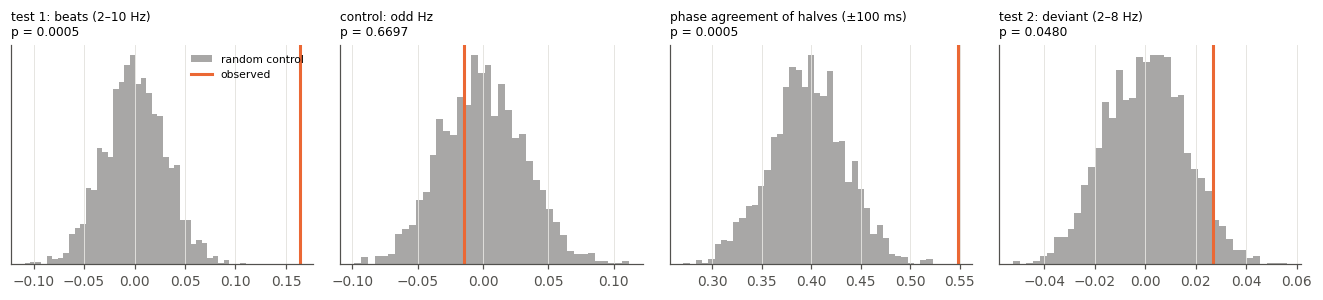

In [10]:
TITLES = {
    "grid_r": "test 1: beats (2–10 Hz)",
    "odd_r": "control: odd Hz",
    "onset_agreement": "phase agreement of halves (±100 ms)",
    "deviant_r": "test 2: deviant (2–8 Hz)",
}
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, (key, title) in zip(axes, TITLES.items()):
    ax.hist(null[key], bins=40, color=NULL_COLOR, alpha=0.5, label="random control")
    ax.axvline(observed[key], color=FP_COLOR, lw=2, label="observed")
    ax.set_title(f"{title}\np = {p[key]:.4f}", loc="left", fontsize=8)
    ax.set_yticks([])
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

**Topography and shape of the beat response.** Each half is aligned to the phase found on the other half, so the shape is not imposed by the search. The time axis is relative: beat onset is set to the N1 minimum minus 100 ms.

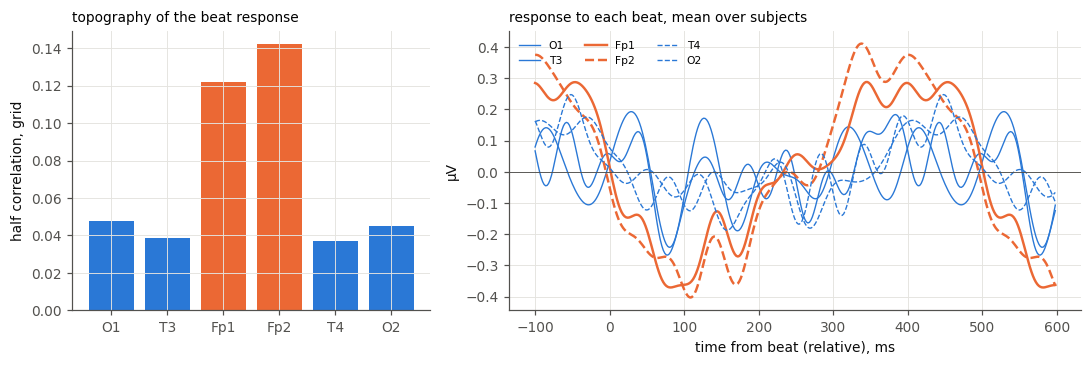

,recordings,half correlation,p
O1,147.0,0.048,0.022
T3,121.0,0.039,0.056
Fp1,155.0,0.122,0.002
Fp2,155.0,0.142,0.002
T4,132.0,0.037,0.072
O2,138.0,0.045,0.040


In [11]:
channels = pd.DataFrame({
    ch: {"recordings": v["n_records"], "half correlation": v["grid_r"]["observed"], "p": v["grid_r"]["p"]}
    for ch, v in saved["channels"].items()
}).T
curves = pd.read_csv(VALIDATION / "metronome_confirm" / "curves_rest.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
colors = [FP_COLOR if ch in metronome.FRONTAL else OTHER_COLOR for ch in channels.index]
axes[0].bar(channels.index, channels["half correlation"], color=colors)
axes[0].set_ylabel("half correlation, grid")
axes[0].set_title("topography of the beat response", loc="left", fontsize=9)
for ch in config.CHANNELS:
    d = curves[(curves["kind"] == "grid") & (curves["channel"] == ch)]
    color = FP_COLOR if ch in metronome.FRONTAL else OTHER_COLOR
    axes[1].plot(d["time_s"] * 1000, d["mean_uv"], color=color, lw=1.6 if ch in metronome.FRONTAL else 0.9,
                 ls="-" if ch in ("Fp1", "O1", "T3") else "--", label=ch)
axes[1].axhline(0, color=viz.TEXT_MUTED, lw=0.6)
axes[1].set_xlabel("time from beat (relative), ms")
axes[1].set_ylabel("µV")
axes[1].set_title("response to each beat, mean over subjects", loc="left", fontsize=9)
axes[1].legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()
channels

**Rest against the Schulte task** (pilot):

In [12]:
pilot = json.loads((VALIDATION / "metronome_pilot" / "metrics.json").read_text(encoding="utf-8"))
pd.DataFrame({
    condition: {
        "recordings": pilot[condition]["n_records"],
        "subjects": pilot[condition]["n_subjects"],
        "test 1 (beats)": pilot[condition]["observed"]["grid_r"],
        "p (beats)": pilot[condition]["p"]["grid_r"],
        "odd Hz control, p": pilot[condition]["p"]["odd_r"],
        "test 2 (deviant, 1–20 Hz), p": pilot[condition]["p"]["deviant_r"],
    }
    for condition in ("rest", "task")
}).rename(columns={"rest": "rest", "task": "Schulte task"}).T

,recordings,subjects,test 1 (beats),p (beats),"odd Hz control, p","test 2 (deviant, 1–20 Hz), p"
rest,155.0,155.0,0.163,5.000e-04,0.670,0.052
Schulte task,314.0,106.0,0.024,1.609e-01,0.664,0.826


At rest the response to the beats is reliable, specific to the grid frequencies and frontal, which is typical of the auditory N1 with an ear reference. It is not found during the Schulte task, when attention is on the visual task and eye artefacts are stronger.

## 5.5 Sensitivity of the method

An ERP CORE response of known size was inserted into real rest recordings at known times, and the same pipeline was run (20 repetitions per size). The noise is built with the plus-minus method (Schimmel, 1967), which cancels any real metronome response. The saved results are read here.

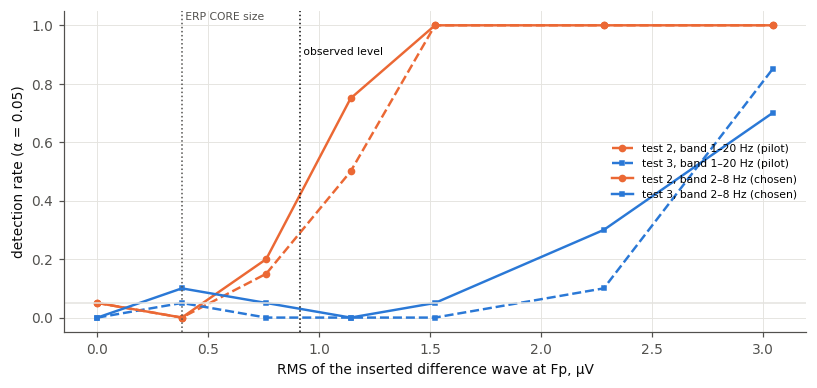

RMS, µV  power of test 2  power of test 3  \
variant_label        amplitude                                              
band 2–8 Hz (chosen) 0.0          0.000             0.05             0.00   
                     1.0          0.380             0.00             0.10   
                     2.0          0.761             0.20             0.05   
                     3.0          1.141             0.75             0.00   
                     4.0          1.521             1.00             0.05   
                     6.0          2.282             1.00             0.30   
                     8.0          3.042             1.00             0.70   
band 1–20 Hz (pilot) 0.0          0.000             0.05             0.00   
                     1.0          0.380             0.00             0.05   
                     2.0          0.761             0.15             0.00   
                     3.0          1.141             0.50             0.00   
                     4.0          1.521             1.00             0.00   
                     6.0          2.282             1.00             0.10   
                     8.0          3.042             1.00             0.85   

                                phase within ±50 ms  deviant position found  
variant_label        amplitude                                               
band 2–8 Hz (chosen) 0.0                      0.299                   0.057  
                     1.0                      0.301                   0.057  
                     2.0                      0.305                   0.075  
                     3.0                      0.291                   0.092  
                     4.0                      0.293                   0.132  
                     6.0                      0.279                   0.225  
                     8.0                      0.266                   0.307  
band 1–20 Hz (pilot) 0.0                      0.299                   0.055  
                     1.0                      0.301                   0.058  
                     2.0                      0.305                   0.073  
                     3.0                      0.291                   0.093  
                     4.0                      0.293                   0.121  
                     6.0                      0.279                   0.206  
                     8.0                      0.266                   0.291

In [13]:
power = pd.read_csv(VALIDATION / "metronome_validation" / "hybrid_power.csv")
labels = {"pilot_1_20Hz": "band 1–20 Hz (pilot)", "mmn_2_8Hz": "band 2–8 Hz (chosen)"}
confirm_band = power[power["variant"] == "mmn_2_8Hz"].sort_values("amplitude")
observed_rms = np.interp(observed["deviant_r"], confirm_band["deviant_r"], confirm_band["difference_rms_uv"])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for variant, style in [("pilot_1_20Hz", "--"), ("mmn_2_8Hz", "-")]:
    d = power[power["variant"] == variant].sort_values("amplitude")
    ax.plot(d["difference_rms_uv"], d["test2_power"], style, marker="o", ms=4, color=FP_COLOR, label=f"test 2, {labels[variant]}")
    ax.plot(d["difference_rms_uv"], d["test3_power"], style, marker="s", ms=3, color=OTHER_COLOR, label=f"test 3, {labels[variant]}")
erp_rms = confirm_band.loc[confirm_band["amplitude"] == 1.0, "difference_rms_uv"].item()
ax.axvline(erp_rms, color=viz.TEXT_MUTED, ls=":", lw=1)
ax.text(erp_rms, 1.02, " ERP CORE size", fontsize=7, color=viz.TEXT_MUTED)
ax.axvline(observed_rms, color="#0b0b0b", ls=":", lw=1)
ax.text(observed_rms, 0.9, " observed level", fontsize=7)
ax.axhline(0.05, color=viz.GRID, lw=1)
ax.set_xlabel("RMS of the inserted difference wave at Fp, µV")
ax.set_ylabel("detection rate (α = 0.05)")
ax.legend(fontsize=7, loc="center right")
plt.tight_layout()
plt.show()

power.assign(variant_label=power["variant"].map(labels)).set_index(["variant_label", "amplitude"])[
    ["difference_rms_uv", "test2_power", "test3_power", "phase_within_50ms_of_bias", "deviant_found"]
].rename(columns={
    "difference_rms_uv": "RMS, µV",
    "test2_power": "power of test 2",
    "test3_power": "power of test 3",
    "phase_within_50ms_of_bias": "phase within ±50 ms",
    "deviant_found": "deviant position found",
})

- Without a signal the false positive rate is about 5%, as it should be.
- Test 2 detects a response only when it is clearly larger than the ERP CORE response.
- The timing of a single recording cannot be recovered, so the extracted curve (test 3) works only for very large responses.

## 5.6 Confirmatory test of the deviant

One run: band 2–8 Hz, 2000 random controls, threshold 0.025 (a second test on the same recordings).

In [14]:
confirm_table = pd.DataFrame({
    "observed": {key: observed[key] for key in ("deviant_r", "curve_energy")},
    "control mean": {key: null[key].mean() for key in ("deviant_r", "curve_energy")},
    "control 95th percentile": {key: np.quantile(null[key], 0.95) for key in ("deviant_r", "curve_energy")},
    "p": {key: p[key] for key in ("deviant_r", "curve_energy")},
}).rename(index={"deviant_r": "test 2: half correlation", "curve_energy": "test 3: curve energy"})
confirm_table["significant at 0.025"] = confirm_table["p"] < metronome.CONFIRM_ALPHA
print(f"observed level from the hybrid calibration: RMS ≈ {observed_rms:.2f} µV at Fp")
confirm_table

observed level from the hybrid calibration: RMS ≈ 0.91 µV at Fp


,observed,control mean,control 95th percentile,p,significant at 0.025
test 2: half correlation,0.027,1.527e-04,0.026,0.048,False
test 3: curve energy,0.034,4.331e-02,0.099,0.549,False


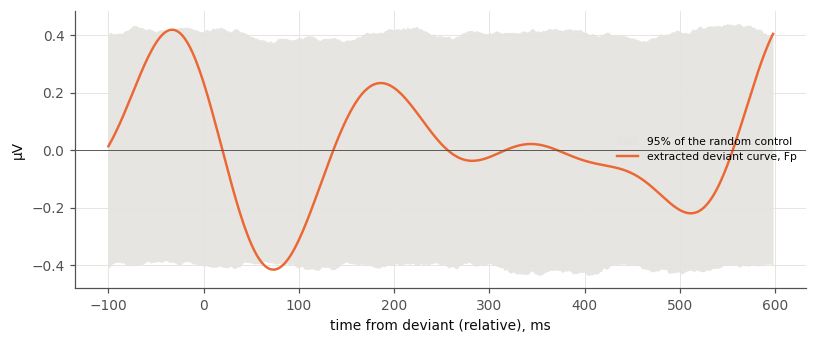

In [15]:
d = curves[(curves["kind"] == "deviant") & (curves["channel"] == "Fp")]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.fill_between(d["time_s"] * 1000, d["null_q025_uv"], d["null_q975_uv"], color=viz.GRID, alpha=0.9, lw=0, label="95% of the random control")
ax.plot(d["time_s"] * 1000, d["mean_uv"], color=FP_COLOR, label="extracted deviant curve, Fp")
ax.axhline(0, color=viz.TEXT_MUTED, lw=0.6)
ax.set_xlabel("time from deviant (relative), ms")
ax.set_ylabel("µV")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

The deviant response is not confirmed: the test missed its threshold and the extracted curve stays within the band of the random control. A large response is ruled out, but a response of typical MMN size is beyond what the method can detect.

## 5.7 Summary

| Claim | Status |
| --- | --- |
| Bonus condition (lower bound of the AUC interval above 0.5) | met |
| Auditory response to the metronome beats found without markers | shown, and absent at odd frequencies |
| The response is frontal | shown |
| Response during the Schulte task | not found |
| Method validated on open data (ERP CORE, hybrid simulation) | done |
| Hardware filter is fourth order and reshapes the MMN | estimated |
| Deviant response (MMN/P3a) | not shown; a large response is ruled out |

Limitations: the phase response of the filter, the physical difference of the deviant tone and whether the metronome played in every recording are unknown. The beat response is not used by the model.